# Proyecto EDA - Palmer Penguins



![Palmer Penguins - Ilustracion oficial](https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/man/figures/lter_penguins.png)

Fuente: ilustraciones de Allison Horst para el proyecto Palmer Penguins.

## Datos del equipo

- Nombre del equipo: Equipo 1
- Integrantes: Alain, Fran D, Lucia P, Agata, Carolina, Cheyenne
- Semana de trabajo: Semana 11/12/13
- Fecha de entrega: martes 28/04/26

### Tabla de plan de trabajo inicial

| Tarea | Persona responsable | Fecha objetivo | Estado |
|---|---|---|---|
| Carga del dataset |Alain  | 15.04.26 | Done |
| Diagnostico inicial |Cheyenne  |15.04.26  | Done |
| Analisis de nulos |Agata |15.04.26 |Done |
| Decisiones de limpieza | Agata |17.04.26  |Done  |
| Analisis univariado |Lucía  |20.04.26  |Done  |
| Analisis bivariado | Fran |20.04.26  |Done  |
| Visualizaciones finales |Alain  | 21.04.26 | Done |
| Redaccion de hallazgos | Cheyenne | 21.04.26 | Done |
| Conclusiones y recomendaciones | Agata | 22.04.26 | Done |
| Dashboard interactivo | Equipo 1 | 24.04.26 | Done |
| Revision final | Lucia | 24.04.26 | Done |
| Preparacion de defensa oral | Fran | 27.04.26 | Done |

### Carga del dataset

In [17]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Busca data/ desde el directorio actual o un nivel arriba
notebook_dir = os.getcwd()

if os.path.exists(os.path.join(notebook_dir, 'data', 'penguins_raw.csv')):
    data_path = os.path.join(notebook_dir, 'data', 'penguins_raw.csv')
else:
    data_path = os.path.join(notebook_dir, '..', 'data', 'penguins_raw.csv')

df = pd.read_csv(os.path.normpath(data_path))

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df.head()

,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A1,Yes,2007-11-11,39.1,18.7,181.0,3750.0,MALE,NaN,NaN,Not enough blood for isotopes.
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A2,Yes,2007-11-11,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454,NaN
2,PAL0708,3,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A1,Yes,2007-11-16,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302,NaN
3,PAL0708,4,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A2,Yes,2007-11-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult not sampled.
4,PAL0708,5,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A1,Yes,2007-11-16,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426,NaN


### 1) Diagnostico inicial

1.Dimensiones   

In [51]:
print(f"Las dimensiones de la tabla son: {df.shape[0]} filas y {df.shape[1]} columnas") 


Las dimensiones de la tabla son: 344 filas y 17 columnas


2.Tipos de datos

In [52]:
print('\nTipos de datos:')
print(df.dtypes)


Tipos de datos:
studyName                  str
Sample Number            int64
Species                    str
Region                     str
Island                     str
Stage                      str
Individual ID              str
Clutch Completion          str
Date Egg                   str
Culmen Length (mm)     float64
Culmen Depth (mm)      float64
Flipper Length (mm)    float64
Body Mass (g)          float64
Sex                        str
Delta 15 N (o/oo)      float64
Delta 13 C (o/oo)      float64
Comments                   str
dtype: object


In [53]:
print('\nInfo general:')
df.info()


Info general:
<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   studyName            344 non-null    str    
 1   Sample Number        344 non-null    int64  
 2   Species              344 non-null    str    
 3   Region               344 non-null    str    
 4   Island               344 non-null    str    
 5   Stage                344 non-null    str    
 6   Individual ID        344 non-null    str    
 7   Clutch Completion    344 non-null    str    
 8   Date Egg             344 non-null    str    
 9   Culmen Length (mm)   342 non-null    float64
 10  Culmen Depth (mm)    342 non-null    float64
 11  Flipper Length (mm)  342 non-null    float64
 12  Body Mass (g)        342 non-null    float64
 13  Sex                  333 non-null    str    
 14  Delta 15 N (o/oo)    330 non-null    float64
 15  Delta 13 C (o/oo)    331 non-null   

3.Nulos por columna 

In [54]:
print('\nNulos por columna:')
print(df.isna().sum())


Nulos por columna:
studyName                0
Sample Number            0
Species                  0
Region                   0
Island                   0
Stage                    0
Individual ID            0
Clutch Completion        0
Date Egg                 0
Culmen Length (mm)       2
Culmen Depth (mm)        2
Flipper Length (mm)      2
Body Mass (g)            2
Sex                     11
Delta 15 N (o/oo)       14
Delta 13 C (o/oo)       13
Comments               290
dtype: int64


4.Duplicados

In [55]:
print('\nDuplicados:', df.duplicated().sum())



Duplicados: 0


### Interpretacion guiada

1. **Que muestra este diagnóstico general.**    

    > El diagnóstico ofrece una visión global del dataset, incluyendo su tamaño, tipos de variables, presencia de valores nulos y posibles duplicados. Permite identificar problemas de calidad de datos antes de comenzar el análisis.  

2. **Que problema de calidad os parece más relevante.**
   > La presencia de valores nulos en variables clave  es el problema más relevante, ya que afecta directamente a la validez del análisis. 

3. **Por que ese problema le importa al cliente.**
   > Porque los valores faltantes pueden sesgar los resultados y llevar a conclusiones incorrectas sobre las diferencias entre especies o la distribución de poblaciones, afectando la toma de decisiones científicas.   

### 2) Limpieza y decisiones de calidad de datos

Realizamos una copia de df orginal para comenzar la limpieza de datos

In [56]:
df_limpio = df.copy()

Reducimos la tabla a las columnas que necesitaremos para el analisis posterior

In [57]:
columnas_interes = [
    'Species', 
    'Island', 
    'Individual ID',
    'Culmen Length (mm)', 
    'Culmen Depth (mm)', 
    'Flipper Length (mm)', 
    'Body Mass (g)', 
    'Sex'
    
]
df_limpio = df[columnas_interes]
df_limpio

,Species,Island,Individual ID,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex
0,Adelie Penguin (Pygoscelis adeliae),Torgersen,N1A1,39.1,18.7,181.0,3750.0,MALE
1,Adelie Penguin (Pygoscelis adeliae),Torgersen,N1A2,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie Penguin (Pygoscelis adeliae),Torgersen,N2A1,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie Penguin (Pygoscelis adeliae),Torgersen,N2A2,NaN,NaN,NaN,NaN,NaN
4,Adelie Penguin (Pygoscelis adeliae),Torgersen,N3A1,36.7,19.3,193.0,3450.0,FEMALE
...,...,...,...,...,...,...,...,...
339,Chinstrap penguin (Pygoscelis antarctica),Dream,N98A2,55.8,19.8,207.0,4000.0,MALE
340,Chinstrap penguin (Pygoscelis antarctica),Dream,N99A1,43.5,18.1,202.0,3400.0,FEMALE
341,Chinstrap penguin (Pygoscelis antarctica),Dream,N99A2,49.6,18.2,193.0,3775.0,MALE
342,Chinstrap penguin (Pygoscelis antarctica),Dream,N100A1,50.8,19.0,210.0,4100.0,MALE


Contado de numero de muestras de cada especie

In [58]:
df_limpio['Species'].value_counts()

Species
Adelie Penguin (Pygoscelis adeliae)          152
Gentoo penguin (Pygoscelis papua)            124
Chinstrap penguin (Pygoscelis antarctica)     68
Name: count, dtype: int64

Transformamos los nombres de la columna "Species" para simplificar la limpieza

In [59]:
df_limpio['Species'] = df_limpio['Species'].str.split().str[0]
df_limpio

,Species,Island,Individual ID,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex
0,Adelie,Torgersen,N1A1,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,N1A2,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,N2A1,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,N2A2,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,N3A1,36.7,19.3,193.0,3450.0,FEMALE
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,N98A2,55.8,19.8,207.0,4000.0,MALE
340,Chinstrap,Dream,N99A1,43.5,18.1,202.0,3400.0,FEMALE
341,Chinstrap,Dream,N99A2,49.6,18.2,193.0,3775.0,MALE
342,Chinstrap,Dream,N100A1,50.8,19.0,210.0,4100.0,MALE


Generación de dataframe para cada especie

In [60]:
filt = (df_limpio['Species'] == 'Adelie')
df_adelie = df_limpio.loc[filt]
df_adelie

,Species,Island,Individual ID,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex
0,Adelie,Torgersen,N1A1,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,N1A2,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,N2A1,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,N2A2,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,N3A1,36.7,19.3,193.0,3450.0,FEMALE
...,...,...,...,...,...,...,...,...
147,Adelie,Dream,N83A2,36.6,18.4,184.0,3475.0,FEMALE
148,Adelie,Dream,N84A1,36.0,17.8,195.0,3450.0,FEMALE
149,Adelie,Dream,N84A2,37.8,18.1,193.0,3750.0,MALE
150,Adelie,Dream,N85A1,36.0,17.1,187.0,3700.0,FEMALE


In [61]:
df_adelie.isnull().sum()

Species                0
Island                 0
Individual ID          0
Culmen Length (mm)     1
Culmen Depth (mm)      1
Flipper Length (mm)    1
Body Mass (g)          1
Sex                    6
dtype: int64

In [62]:
filt = (df_limpio['Species'] == 'Gentoo')
df_gentoo = df_limpio.loc[filt]
df_gentoo

,Species,Island,Individual ID,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex
152,Gentoo,Biscoe,N31A1,46.1,13.2,211.0,4500.0,FEMALE
153,Gentoo,Biscoe,N31A2,50.0,16.3,230.0,5700.0,MALE
154,Gentoo,Biscoe,N32A1,48.7,14.1,210.0,4450.0,FEMALE
155,Gentoo,Biscoe,N32A2,50.0,15.2,218.0,5700.0,MALE
156,Gentoo,Biscoe,N33A1,47.6,14.5,215.0,5400.0,MALE
...,...,...,...,...,...,...,...,...
271,Gentoo,Biscoe,N38A2,NaN,NaN,NaN,NaN,NaN
272,Gentoo,Biscoe,N39A1,46.8,14.3,215.0,4850.0,FEMALE
273,Gentoo,Biscoe,N39A2,50.4,15.7,222.0,5750.0,MALE
274,Gentoo,Biscoe,N43A1,45.2,14.8,212.0,5200.0,FEMALE


In [63]:
df_gentoo.isnull().sum()

Species                0
Island                 0
Individual ID          0
Culmen Length (mm)     1
Culmen Depth (mm)      1
Flipper Length (mm)    1
Body Mass (g)          1
Sex                    5
dtype: int64

In [64]:
filt = (df_limpio['Species'] == 'Chinstrap')
df_chinstrap = df_limpio.loc[filt]
df_chinstrap

,Species,Island,Individual ID,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex
276,Chinstrap,Dream,N61A1,46.5,17.9,192.0,3500.0,FEMALE
277,Chinstrap,Dream,N61A2,50.0,19.5,196.0,3900.0,MALE
278,Chinstrap,Dream,N62A1,51.3,19.2,193.0,3650.0,MALE
279,Chinstrap,Dream,N62A2,45.4,18.7,188.0,3525.0,FEMALE
280,Chinstrap,Dream,N64A1,52.7,19.8,197.0,3725.0,MALE
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,N98A2,55.8,19.8,207.0,4000.0,MALE
340,Chinstrap,Dream,N99A1,43.5,18.1,202.0,3400.0,FEMALE
341,Chinstrap,Dream,N99A2,49.6,18.2,193.0,3775.0,MALE
342,Chinstrap,Dream,N100A1,50.8,19.0,210.0,4100.0,MALE


In [65]:
df_chinstrap.isnull().sum()

Species                0
Island                 0
Individual ID          0
Culmen Length (mm)     0
Culmen Depth (mm)      0
Flipper Length (mm)    0
Body Mass (g)          0
Sex                    0
dtype: int64

Calculamos la mediana de especie Adelie para sustituir los valores nulos

In [66]:

columnas = ['Culmen Length (mm)', 'Culmen Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)']

for col in columnas:
    mediana_adelie = df_adelie[col].median()
    print(f"Mediana de '{col}': {mediana_adelie}") 





Mediana de 'Culmen Length (mm)': 38.8
Mediana de 'Culmen Depth (mm)': 18.4
Mediana de 'Flipper Length (mm)': 190.0
Mediana de 'Body Mass (g)': 3700.0


Calculamos la mediana de especie Gentoo para sustituir los valores nulos

In [67]:

columnas = ['Culmen Length (mm)', 'Culmen Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)']

for col in columnas:
    mediana_gentoo = df_gentoo[col].median()
    print(f"Mediana de '{col}': {mediana_gentoo}") 

Mediana de 'Culmen Length (mm)': 47.3
Mediana de 'Culmen Depth (mm)': 15.0
Mediana de 'Flipper Length (mm)': 216.0
Mediana de 'Body Mass (g)': 5000.0


Imputación de mediana por especie

In [68]:
df_adelie[columnas] = df_adelie[columnas].fillna(df_adelie[columnas].median())
df_adelie


,Species,Island,Individual ID,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex
0,Adelie,Torgersen,N1A1,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,N1A2,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,N2A1,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,N2A2,38.8,18.4,190.0,3700.0,NaN
4,Adelie,Torgersen,N3A1,36.7,19.3,193.0,3450.0,FEMALE
...,...,...,...,...,...,...,...,...
147,Adelie,Dream,N83A2,36.6,18.4,184.0,3475.0,FEMALE
148,Adelie,Dream,N84A1,36.0,17.8,195.0,3450.0,FEMALE
149,Adelie,Dream,N84A2,37.8,18.1,193.0,3750.0,MALE
150,Adelie,Dream,N85A1,36.0,17.1,187.0,3700.0,FEMALE


In [69]:
df_gentoo[columnas] = df_gentoo[columnas].fillna(df_gentoo[columnas].median())
df_gentoo

,Species,Island,Individual ID,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex
152,Gentoo,Biscoe,N31A1,46.1,13.2,211.0,4500.0,FEMALE
153,Gentoo,Biscoe,N31A2,50.0,16.3,230.0,5700.0,MALE
154,Gentoo,Biscoe,N32A1,48.7,14.1,210.0,4450.0,FEMALE
155,Gentoo,Biscoe,N32A2,50.0,15.2,218.0,5700.0,MALE
156,Gentoo,Biscoe,N33A1,47.6,14.5,215.0,5400.0,MALE
...,...,...,...,...,...,...,...,...
271,Gentoo,Biscoe,N38A2,47.3,15.0,216.0,5000.0,NaN
272,Gentoo,Biscoe,N39A1,46.8,14.3,215.0,4850.0,FEMALE
273,Gentoo,Biscoe,N39A2,50.4,15.7,222.0,5750.0,MALE
274,Gentoo,Biscoe,N43A1,45.2,14.8,212.0,5200.0,FEMALE


Unimos los 3 dataframes en uno solo

In [70]:
df_limpio = pd.concat([df_adelie, df_gentoo, df_chinstrap], ignore_index=True)
df_limpio


,Species,Island,Individual ID,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex
0,Adelie,Torgersen,N1A1,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,N1A2,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,N2A1,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,N2A2,38.8,18.4,190.0,3700.0,NaN
4,Adelie,Torgersen,N3A1,36.7,19.3,193.0,3450.0,FEMALE
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,N98A2,55.8,19.8,207.0,4000.0,MALE
340,Chinstrap,Dream,N99A1,43.5,18.1,202.0,3400.0,FEMALE
341,Chinstrap,Dream,N99A2,49.6,18.2,193.0,3775.0,MALE
342,Chinstrap,Dream,N100A1,50.8,19.0,210.0,4100.0,MALE


Sustitución de valores nulos en la columna Sex por UNKNOWN

In [71]:
df_limpio['Sex'] = df_limpio['Sex'].fillna('UNKNOWN') 
df_limpio

,Species,Island,Individual ID,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex
0,Adelie,Torgersen,N1A1,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,N1A2,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,N2A1,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,N2A2,38.8,18.4,190.0,3700.0,UNKNOWN
4,Adelie,Torgersen,N3A1,36.7,19.3,193.0,3450.0,FEMALE
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,N98A2,55.8,19.8,207.0,4000.0,MALE
340,Chinstrap,Dream,N99A1,43.5,18.1,202.0,3400.0,FEMALE
341,Chinstrap,Dream,N99A2,49.6,18.2,193.0,3775.0,MALE
342,Chinstrap,Dream,N100A1,50.8,19.0,210.0,4100.0,MALE


In [72]:
df_limpio.describe()


,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g)
count,344.000000,344.000000,344.000000,344.000000
mean,43.916860,17.148547,200.927326,4202.616279
std,5.453713,1.973601,14.056652,801.231551
min,32.100000,13.100000,172.000000,2700.000000
25%,39.200000,15.575000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.250000,4756.250000
max,59.600000,21.500000,231.000000,6300.000000


In [73]:
# Tabla de frecuencias: Islas (filas) vs Especies (columnas)
tabla_islas = pd.crosstab(df_limpio['Island'], df_limpio['Species'], margins=True, margins_name="Total")
print(tabla_islas)

Species    Adelie  Chinstrap  Gentoo  Total
Island                                     
Biscoe         44          0     124    168
Dream          56         68       0    124
Torgersen      52          0       0     52
Total         152         68     124    344


In [74]:
# Tabla de frecuencias: Especies (filas) vs Sexo (columnas)
tabla_sexo = pd.crosstab(df_limpio['Species'], df_limpio['Sex'].fillna('Unknown'), margins=True, margins_name="Total")
print(tabla_sexo)

Sex        FEMALE  MALE  UNKNOWN  Total
Species                                
Adelie         73    73        6    152
Chinstrap      34    34        0     68
Gentoo         58    61        5    124
Total         165   168       11    344


Comprobación antiperdida tras la limpieza

In [75]:
print('Filas originales:', len(df))
print('Filas tras limpieza:', len(df_limpio))
print('\nNulos tras limpieza:')
print(df_limpio.isna().sum())
df_limpio.info()

Filas originales: 344
Filas tras limpieza: 344

Nulos tras limpieza:
Species                0
Island                 0
Individual ID          0
Culmen Length (mm)     0
Culmen Depth (mm)      0
Flipper Length (mm)    0
Body Mass (g)          0
Sex                    0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Species              344 non-null    object 
 1   Island               344 non-null    str    
 2   Individual ID        344 non-null    str    
 3   Culmen Length (mm)   344 non-null    float64
 4   Culmen Depth (mm)    344 non-null    float64
 5   Flipper Length (mm)  344 non-null    float64
 6   Body Mass (g)        344 non-null    float64
 7   Sex                  344 non-null    str    
dtypes: float64(4), object(1), str(3)
memory usage: 27.1+ KB


### Tabla de decisiones de calidad del dato


| Problema detectado | Columna afectada | Decision tomada | Justificacion | Impacto esperado |
|---|---|---|---|---|
|Valores nulos en variable categórica |Sex |Imputación con categoría "UNKNOWN" |Permite conservar registros sin eliminar información relevante|Ligera pérdida de precisión en análisis por sexo |
|Valores nulos en variables numéricas clave |Culmen Length, Culmen Depth, Flipper Length, Body Mass |Imputación con la mediana de cada especie|Se utiliza la mediana en lugar de la media porque es más robusta frente a valores extremos y permite mantener mejor la distribución original de los datos. Además, se decidió no eliminar las filas con nulos debido a su baja proporción. Esta decisión prioriza la conservación del dataset frente a una posible ligera pérdida de variabilidad |Minimiza el sesgo, mantiene el tamaño del dataset y permite análisis comparables entre especies
|Necesidad de analizar diferencias entre especies sin mezclar distribuciones |Species |Generación de dataframe para cada especie |Separar el dataset por especie permite analizar patrones morfológicos de forma más precisa, evitando la mezcla de distribuciones que podría ocultar diferencias relevantes. Además, facilita una imputación y análisis más coherentes |Mejora la interpretación de los resultados y permite comparaciones más claras entre especies |


### Interpretacion guiada

1. Que decision de limpieza tuvo mayor impacto en el dataset.
   
    ```
    Eliminamos todas las columnas (9) que no aportaban datos relevantes a nuestro estudio  
    ```     
2. Que riesgo se evita con esa decision.  
    
    ````
    Eliminar columnas irrelevantes reduce el ruido y hace que el análisis sea más fiable. 
    ````
      
3. Que posible efecto secundario puede introducir.
    
    ```
    Las columnas irrelevantes añaden información que no aporta nada, pero sí puede:     
    •     distorsionar patrones     
    •     aumentar la variabilidad      
    •     generar correlaciones falsas      
    •     confundir modelos o visualizaciones  
    ```   

### 3) Analisis univariado

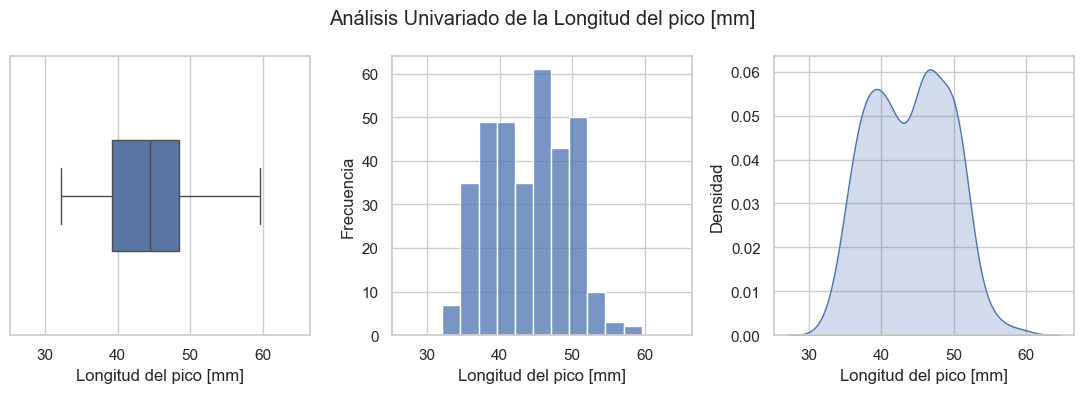

In [77]:
var = 'Culmen Length (mm)'
var_title = 'Longitud del pico [mm]'

# Ajustes de la figura de Matplotlib (crea una figura unificada con varios gráficos, que comparten el eje x)
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(11, 4), sharex=True)


# Plotea el boxplot (1º gráfico)
sns.boxplot(data=df_limpio[var], ax=ax[0], orient='h', width=0.4)
ax[0].set_xlabel(var_title)


# Plotea el histograma (2º gráfico)
sns.histplot(data=df_limpio[var], ax=ax[1], kde=False)
ax[1].set_xlabel(var_title)
ax[1].set_ylabel('Frecuencia')


# Plotea la curva de densidad (3º gráfico)
sns.kdeplot(data=df_limpio[var], ax=ax[2], fill=True)
ax[2].set_xlabel(var_title)
ax[2].set_ylabel('Densidad')


fig.suptitle('Análisis Univariado de la ' + var_title)

plt.tight_layout()



### 📊 Interpretación gráfica:

* Qué muestra:

```
La distribución conjunta de la longitud del pico en las tres especies de pingüinos.
```

* Qué patrón aparece:

```
Se observan dos grupos claros de tamaños, uno con picos más cortos y otro con picos más largos, indicando una distribución bimodal.
```

* Por qué le importa al cliente

```
Revela diferencias morfológicas importantes entre especies y sugiere que la longitud del pico es una variable útil para distinguir grupos dentro de la población.
```

* Limitación:

```
Al estar las especies mezcladas, no permite identificar qué especie corresponde a cada grupo ni analizar la causa del patrón sin separar los datos.
```

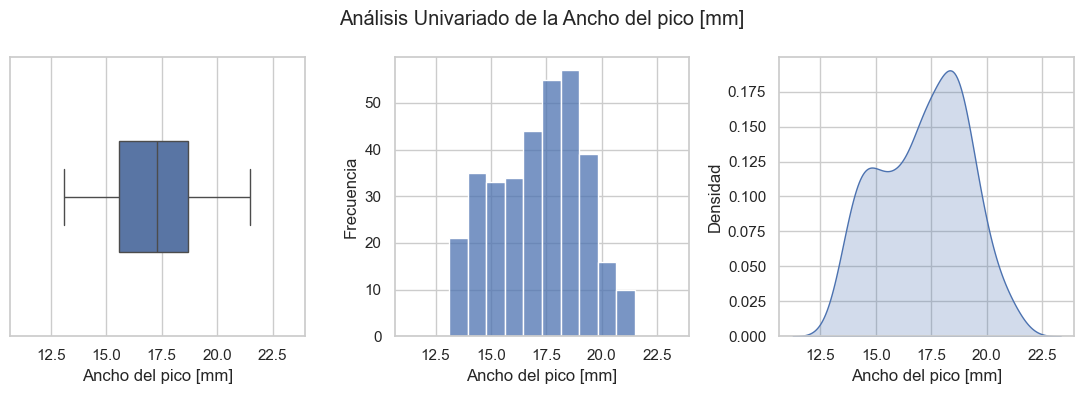

In [76]:
var = 'Culmen Depth (mm)'
var_title = 'Ancho del pico [mm]'

# Ajustes de la figura de Matplotlib (crea una figura unificada con varios gráficos, que comparten el eje x)
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(11, 4), sharex=True)


# Plotea el boxplot (1º gráfico)
sns.boxplot(data=df_limpio[var], ax=ax[0], orient='h', width=0.4)
ax[0].set_xlabel(var_title)


# Plotea el histograma (2º gráfico)
sns.histplot(data=df_limpio[var], ax=ax[1], kde=False)
ax[1].set_xlabel(var_title)
ax[1].set_ylabel('Frecuencia')


# Plotea la curva de densidad (3º gráfico)
sns.kdeplot(data=df_limpio[var], ax=ax[2], fill=True)
ax[2].set_xlabel(var_title)
ax[2].set_ylabel('Densidad')


fig.suptitle('Análisis Univariado de la ' + var_title)

plt.tight_layout()



### 📊 Interpretación gráfica:


* Qué muestra:

```
La distribución conjunta de la anchura del pico en las tres especies de pingüinos.
```

* Qué patrón aparece:

```
Los valores se concentran en torno a 17–18 mm, con un rango relativamente estrecho y sin grandes separaciones entre grupos.
```

* Por qué le importa al cliente:

```
Indica que, a diferencia de la longitud, la profundidad del pico es más homogénea entre especies, lo que sugiere menor variabilidad morfológica en esta medida.
```

* Limitación:

```
Al estar las especies mezcladas, no permite ver qué parte de la variación corresponde a cada especie ni si existen diferencias sutiles entre grupos.
```

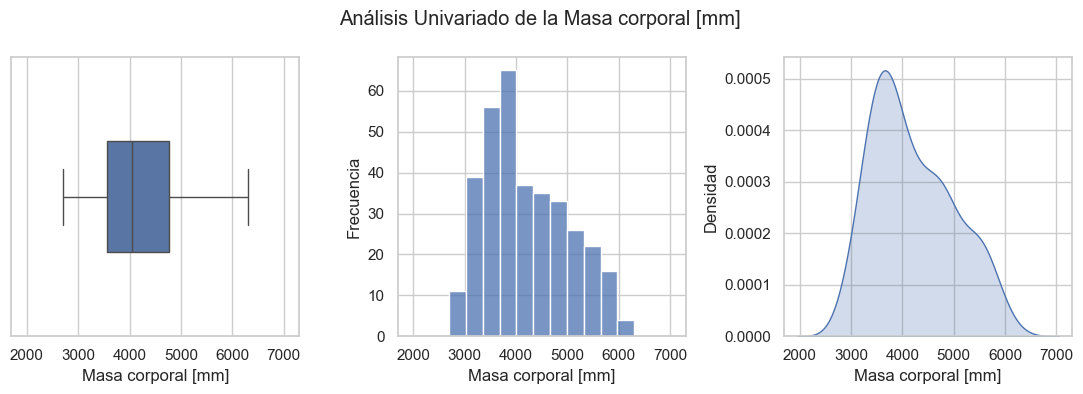

In [78]:
var = 'Body Mass (g)'
var_title = 'Masa corporal [mm]'

# Ajustes de la figura de Matplotlib (crea una figura unificada con varios gráficos, que comparten el eje x)
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(11, 4), sharex=True)


# Plotea el boxplot (1º gráfico)
sns.boxplot(data=df_limpio[var], ax=ax[0], orient='h', width=0.4)
ax[0].set_xlabel(var_title)


# Plotea el histograma (2º gráfico)
sns.histplot(data=df_limpio[var], ax=ax[1], kde=False)
ax[1].set_xlabel(var_title)
ax[1].set_ylabel('Frecuencia')


# Plotea la curva de densidad (3º gráfico)
sns.kdeplot(data=df_limpio[var], ax=ax[2], fill=True)
ax[2].set_xlabel(var_title)
ax[2].set_ylabel('Densidad')


fig.suptitle('Análisis Univariado de la ' + var_title)

plt.tight_layout()



### 📊 Interpretación gráfica:

* Qué muestra:
```
La distribución conjunta de la masa corporal de las tres especies de pingüinos.
```

* Qué patrón aparece:
```
La mayoría de valores se concentran entre 3000 y 6000 g, con un pico claro alrededor de 4000 g, indicando un patrón central dominante.
```
* Por qué le importa al cliente:
```
Refleja el tamaño típico de los pingüinos y permite detectar diferencias generales de robustez entre especies, útil para entender su biología y segmentación.
```
* Limitación:
```
Al estar las especies mezcladas, no permite distinguir qué parte de la variación corresponde a cada especie, ni identificar si existen grupos diferenciados dentro de la distribución.
```

### Análisis de variables categóricas:

En este caso seleccionamos la variable 'Species'

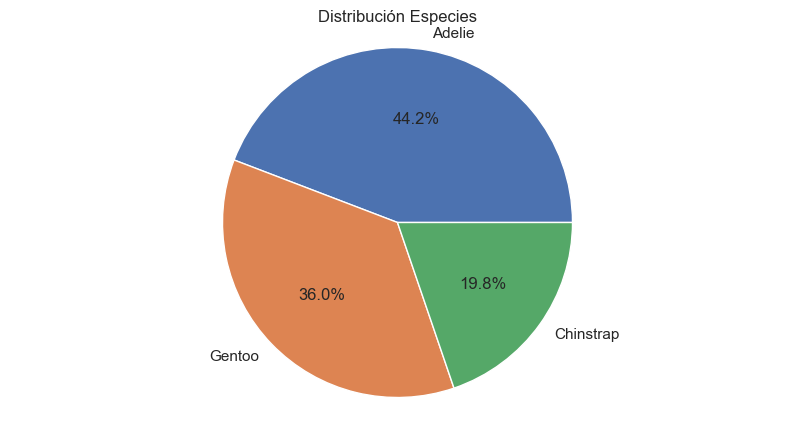

In [79]:
# Frecuencias
df_limpio['Species'].value_counts()

# Proporciones
df_limpio['Species'].value_counts(normalize=True)

# Gráfico de barras
df_limpio['Species'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'  # muestra porcentajes con 1 decimal
)

plt.axis('equal')
plt.title('Distribución Especies')
plt.show()


### 📊 Interpretación gráfica:


* Qué muestra:
```
La proporción de las tres especies de pingüinos presentes en el conjunto de datos.
```

* Qué patrón aparece:
```
Una distribución desigual, donde Adelie es la especie más abundante, seguida de Gentoo y, en menor proporción, Chinstrap.
```

* Por qué le importa al cliente:
```
Permite entender qué especies dominan la muestra, algo clave para interpretar correctamente los análisis posteriores y evitar conclusiones sesgadas.
```
* Limitación:
```
Solo muestra proporciones generales: no informa sobre características, variabilidad ni diferencias internas de cada especie.
```

### 4) Analisis bivariado

### Apoyo visual oficial para variables morfologicas

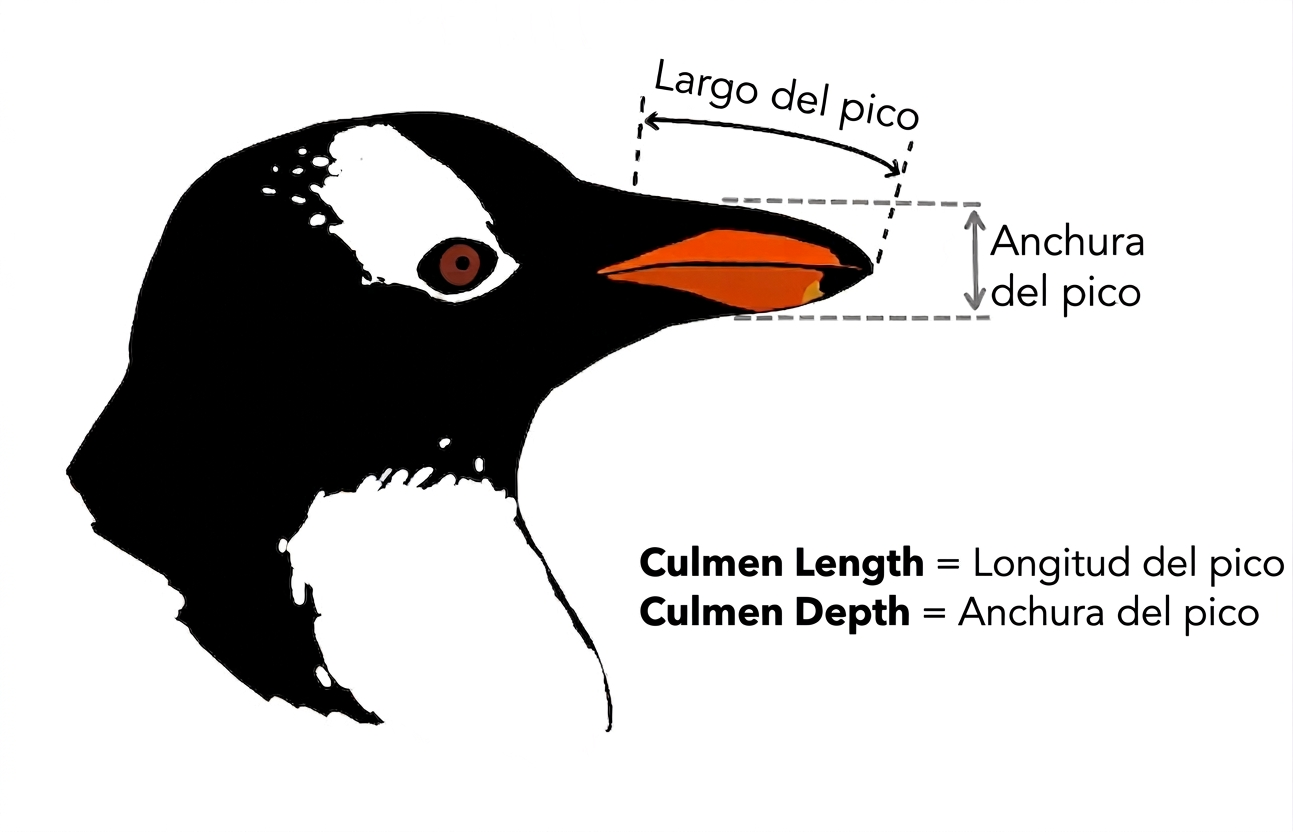
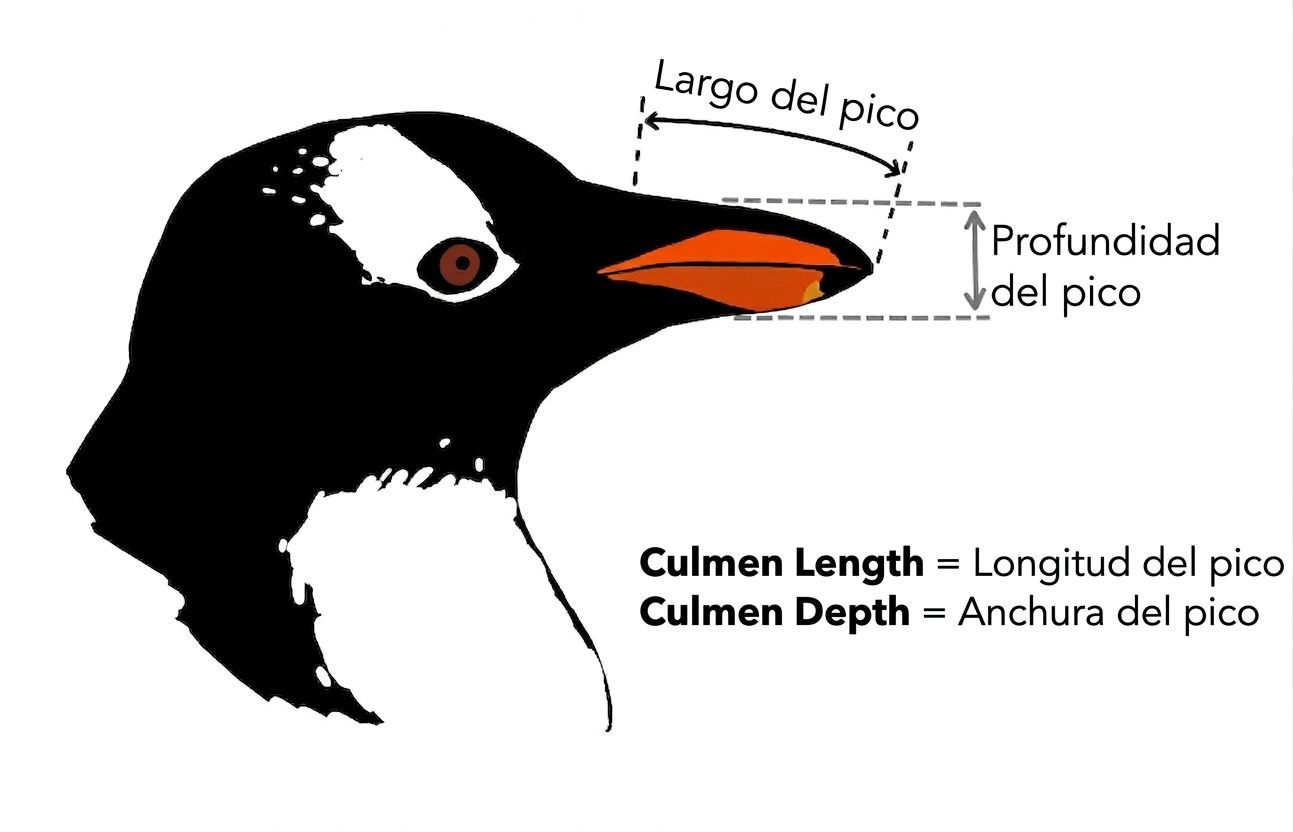

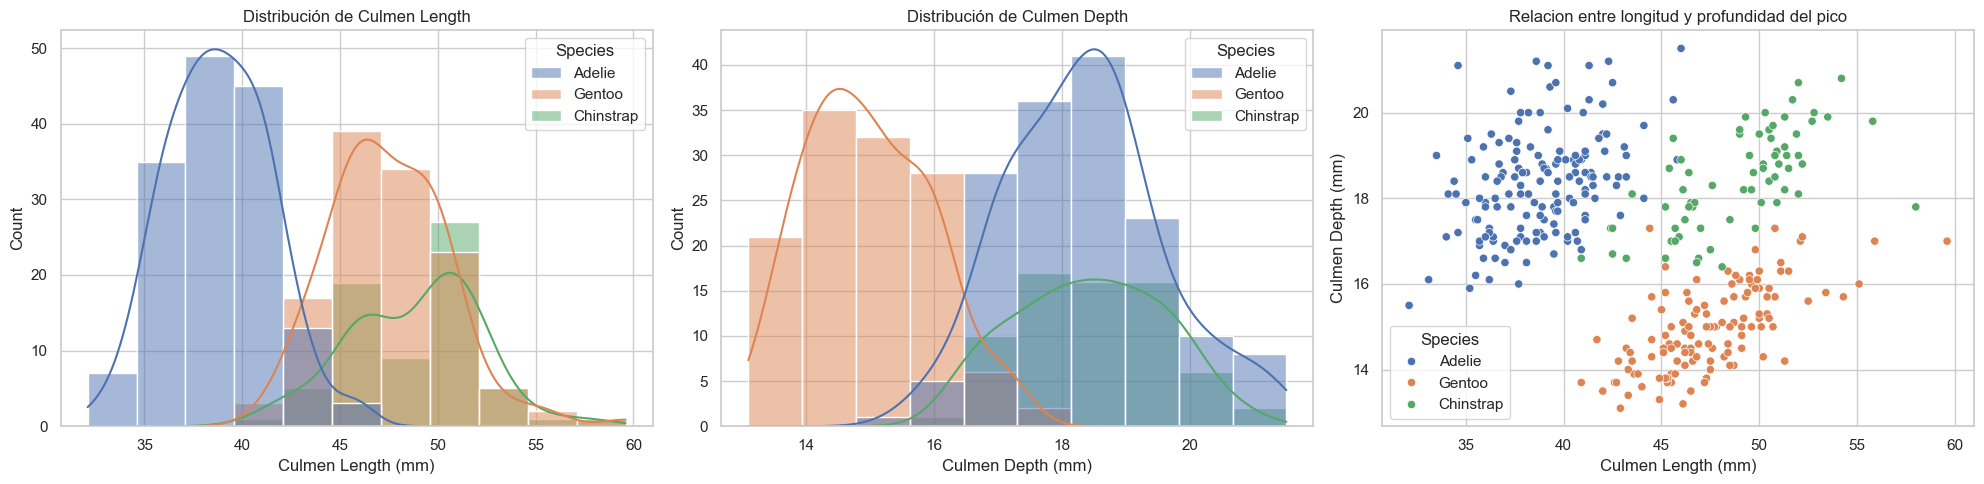

In [80]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

#Histograma 1: Culmen Length
sns.histplot(
    data=df_limpio,
    x="Culmen Length (mm)",
    hue="Species",
    kde=True,
    ax=axes[0]
)
axes[0].set_title("Distribución de Culmen Length")

# Histograma 2: Culmen Depth
sns.histplot(
    data=df_limpio,
    x="Culmen Depth (mm)",
    hue="Species",
    kde=True,
    ax=axes[1]
)
axes[1].set_title("Distribución de Culmen Depth")

# Scartter plot: Relacion numerica-numerica (ejemplo base)
sns.scatterplot(data=df_limpio, x='Culmen Length (mm)', y='Culmen Depth (mm)', hue='Species', ax=axes[2])
axes[2].set_title("Relacion entre longitud y profundidad del pico")

plt.tight_layout()
plt.show()

### 📊Interpretación guiada
1. Qué evidencia observamos:
```
    Las distribuciones de Culmen Length y Culmen Depth muestran patrones distintos por especie, con separaciones claras en la longitud y más solapamiento en la profundidad.
    El scatterplot revela tres nubes diferenciadas, cada una correspondiente a una especie, con combinaciones características de longitud–profundidad.
```

2. Qué interpretación proponemos:
```
    La longitud del pico es una variable muy discriminativa entre especies (especialmente Gentoo vs Adelie/Chinstrap).
    La profundidad del pico también ayuda, pero con más solapamiento.
    La relación conjunta (scatterplot) muestra que cada especie ocupa un espacio morfológico propio, confirmando que ambas medidas combinadas permiten distinguirlas con bastante 
    claridad.
```
3. Qué implicación tiene para el cliente:
```
    El cliente puede clasificar especies o segmentar individuos usando solo estas dos variables, lo que simplifica modelos y dashboards.
    También puede comunicar diferencias morfológicas de forma visual y comprensible, útil para informes, educación o toma de decisiones biológicas.
```
4. Qué limitación o sesgo puede afectar esta interpretación:
```
    Las conclusiones dependen de la calidad y representatividad del dataset: si alguna especie está infrarepresentada, los patrones pueden parecer más o menos claros de lo 
    que realmente son.
    No se consideran otros factores (edad, sexo, temporada, isla), que podrían influir en las medidas y generar solapamientos o separaciones artificiales.
    El análisis es descriptivo, no causal: no explica por qué las especies difieren, solo muestra que lo hacen.
```

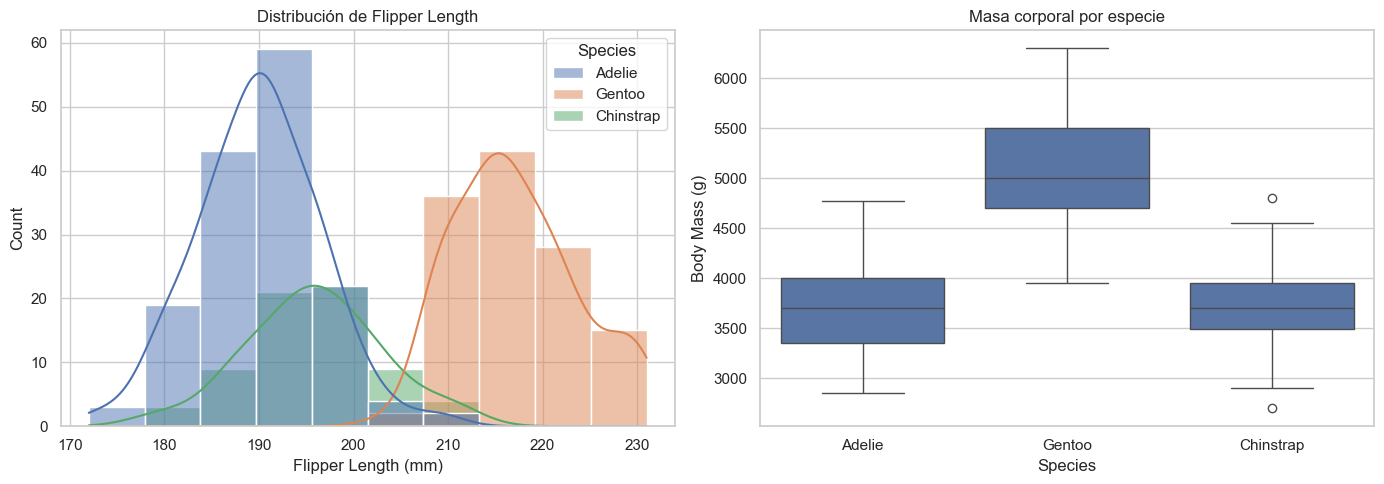

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de Flipper Length
sns.histplot(
    data=df_limpio,
    x="Flipper Length (mm)",
    hue="Species",
    kde=True,
    ax=axes[0]
)
axes[0].set_title("Distribución de Flipper Length")

# Boxplot de Body Mass por especie
sns.boxplot(
    data=df_limpio,
    x='Species',
    y='Body Mass (g)',
    ax=axes[1]
)
axes[1].set_title("Masa corporal por especie")

plt.tight_layout()
plt.show()

1. Qué evidencia observamos:
```
    En la distribución de Flipper Length, las tres especies muestran rangos claramente diferenciados, con Gentoo teniendo las aletas más largas, Adelie las más cortas y Chinstrap 
    en un punto intermedio.
    En el boxplot de Body Mass, Gentoo vuelve a destacar como la especie más pesada, mientras que Adelie y Chinstrap presentan masas corporales más bajas y más cercanas entre sí. 
    También se observan outliers en la especie Chinstrap, el hecho de que sean unicamente dos valores no afectan al análisis. 
```
2. Qué interpretación proponemos:
```
    Existe una relación proporcional entre el tamaño las aletas y la masa total. Esto indica que la longitud de la aleta es un excelente predictor del peso del pingüino. 
    Gentoo: Se sitúan en el cuadrante superior derecho del análisis. Son los "pesos pesados" con las aletas más largas.
    Adelie y Chinstrap: Aunque los Adelie son los más pequeños, ambas especies compiten en rangos similares, creando un solapamiento en la parte inferior izquierda del gráfico.
```
3. Qué implicación tiene para el cliente:
```
    Estas dos variables permiten diferenciar especies de forma muy clara, lo que es útil para clasificación, dashboards y comunicación visual.
    También ayudan al cliente a explicar variaciones biológicas clave entre especies, lo que puede ser relevante para estudios de comportamiento, conservación o divulgación.
```
4. Qué limitación o sesgo puede afectar esta interpretación:
```
    Las diferencias observadas pueden depender del tamaño de muestra por especie: si alguna está sobrerrepresentada, los patrones pueden parecer más marcados.
    No se consideran factores como edad, sexo, temporada o isla, que pueden influir en la masa corporal y la longitud de las aletas.
    El análisis es descriptivo, por lo que no permite afirmar causas, solo mostrar patrones.
```

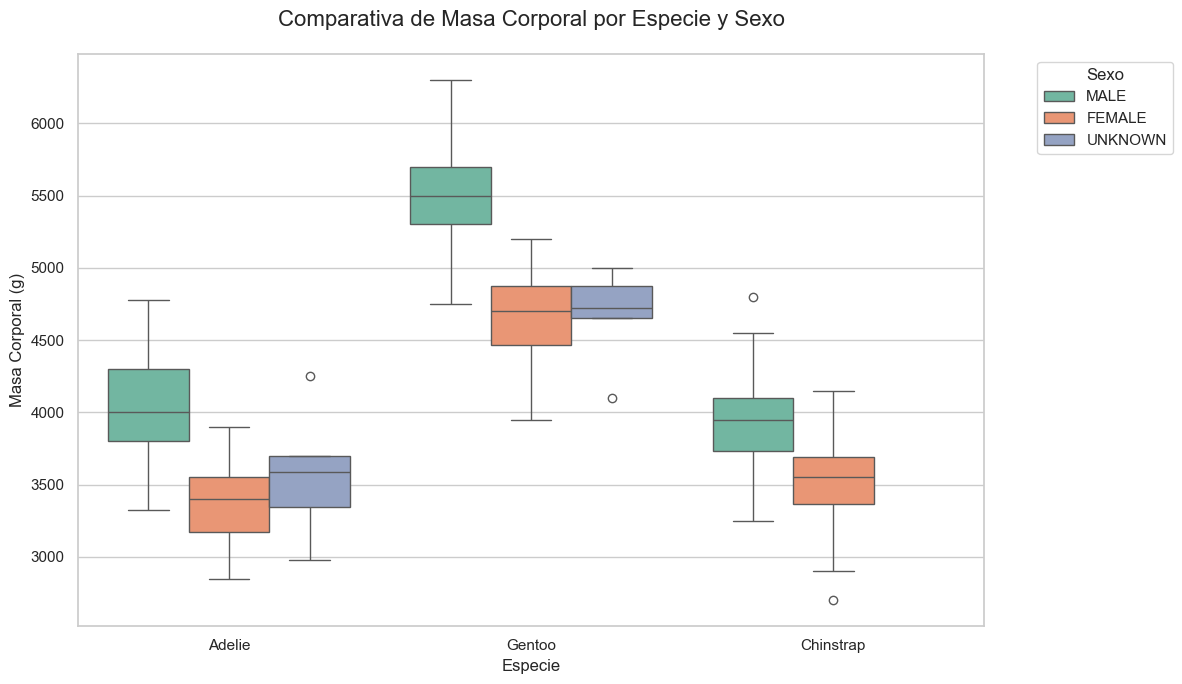

In [82]:

# Configuramos el estilo para que sea profesional
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 7))

# 'x' para las especies, 'y' para el tamaño, y 'hue' para separar por sexo
sns.boxplot(data=df_limpio, x='Species', y='Body Mass (g)', hue='Sex', palette='Set2')

# Personalización de etiquetas
plt.title('Comparativa de Masa Corporal por Especie y Sexo', fontsize=16, pad=20)
plt.xlabel('Especie', fontsize=12)
plt.ylabel('Masa Corporal (g)', fontsize=12)
plt.legend(title='Sexo', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

```
Dimorfismo Sexual Constante: En las tres especies, la caja de los machos (Male) siempre está situada más arriba que la de las hembras (Female). Esto confirma que, independientemente de la especie, los machos tienden a ser más grandes.

La "Superioridad" del Gentoo: Veréis que incluso las hembras Gentoo suelen ser más pesadas que los machos de las especies Adelie y Chinstrap.

Solapamiento en Adelie y Chinstrap: Veréis que estas dos especies tienen rangos de peso muy parecidos, lo que refuerza vuestra observación de que son las especies más pequeñas y similares entre sí.
```

### 5) Visualizacion final

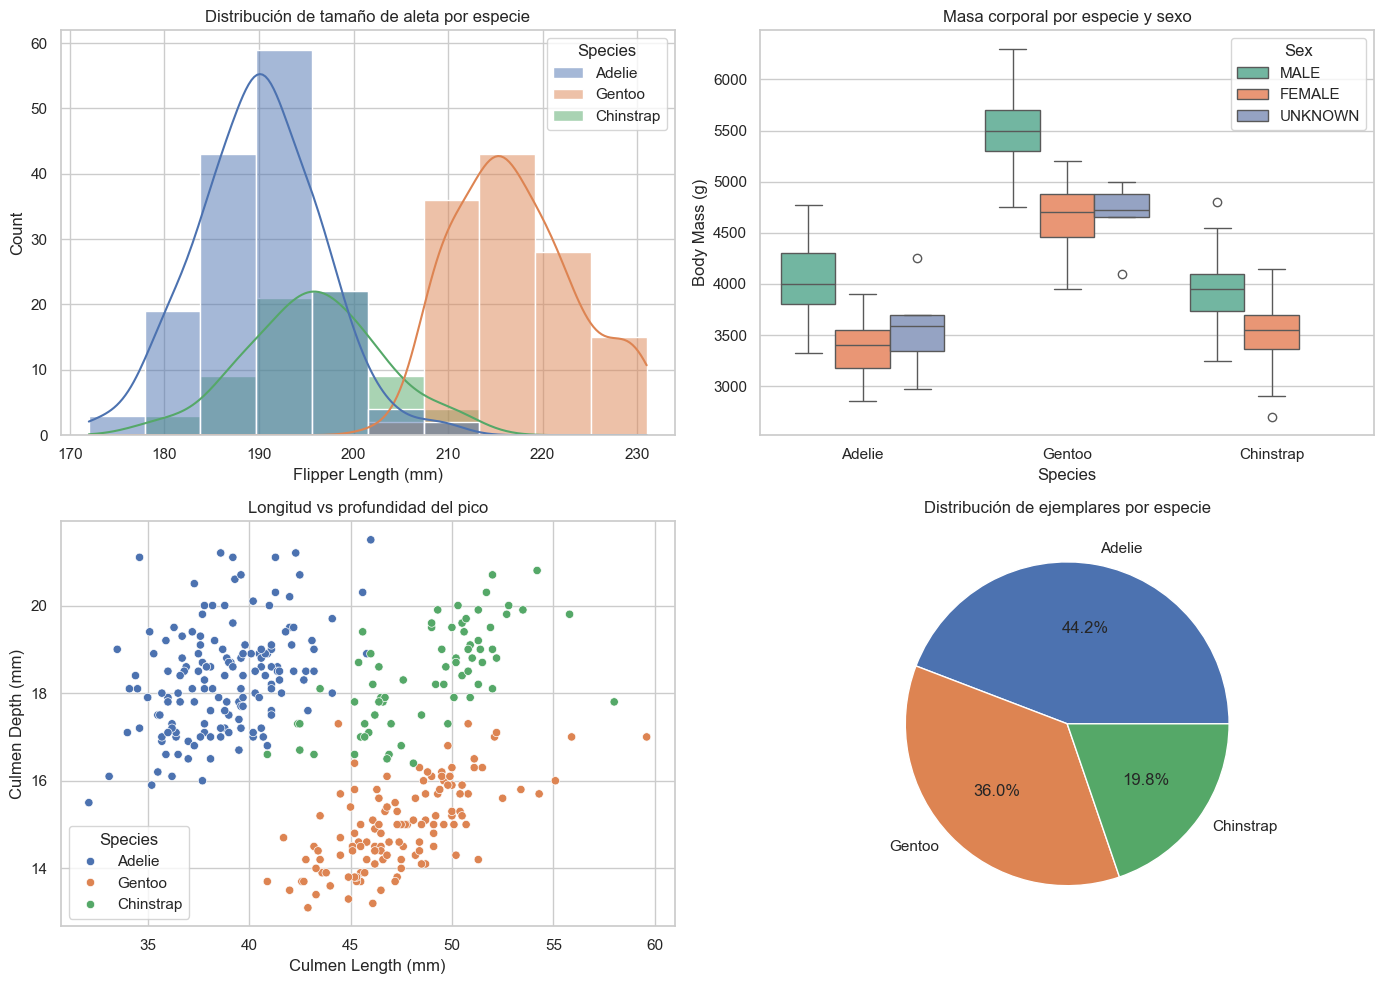

In [83]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# TODO: reemplazad o ajustad estos graficos segun vuestra seleccion final
sns.histplot(data=df_limpio,x="Flipper Length (mm)",hue="Species",kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribución de tamaño de aleta por especie')

sns.boxplot(data=df_limpio, x='Species', y='Body Mass (g)', hue='Sex', palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title('Masa corporal por especie y sexo')

sns.scatterplot(data=df_limpio, x='Culmen Length (mm)', y='Culmen Depth (mm)', hue='Species', ax=axes[1, 0], legend=True)
axes[1, 0].set_title('Longitud vs profundidad del pico')

df_limpio['Species'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%', ax=axes[1, 1])
axes[1, 1].set_title('Distribución de ejemplares por especie')

plt.tight_layout()
plt.show()

### 5) Interpretación guiada del panel final

* **Mensaje principal**:
```
El análisis de los datos revela que la morfología del culmen (pico) y la masa corporal no son solo medidas físicas, sino firmas biológicas que separan a las especies en clústeres estadísticos casi perfectos. El dataset confirma que existe una especialización morfológica: mientras que algunas especies se solapan en peso (Adelie y Chinstrap), se separan drásticamente por la arquitectura de su pico.
```
```
El dataset muestra una segmentación clara de la población: la morfología (aletas y pico) permite identificar especies de forma unívoca y existe un claro patrón de dimorfismo sexual reflejado por las diferencias en la masa corporal entre machos y hembras.
```

* **Gráfico que mejor respalda el mensaje**:
```
El histograma de Longitud de Aleta por especie muestra que las especies Adelie y Chinstrap se "cruzan" mucho, lo que indica que la aleta NO es un buen diferenciador entre estas dos especies.

Sin embargo, en Gentoo hay un solapamiento mínimo o inexistente. El histograma de los Gentoo empieza casi donde terminan los otros. Esto confirma que la aleta es un aislante estadístico para esta especie.

```
```
El Boxplot muestra las diferencias de masa corporal según especie y sexo. Existe un solapamiento casi total entre las cajas de Adelie y Chinstrap, en cambio Gentoo se situa en un rango de masa corporal significativamente superior, sobre todo, en el caso de lo machos.

En las tres especies se observa un claro dimorfismo sexual en el que los machos presentan mayor masa corporal que la hembras. Hay individuos en puntos aislados (outliers) que no alteran la tendencia general pero que deben ser observados.

```
```
El Scatter Plot de Longitud del Pico vs. Ancho del Pico.
A diferencia de otros gráficos, este es el "mapa de identidad" definitivo:

Los Adelie se agrupan en la zona de picos cortos y profundos.

Los Chinstrap en picos largos y profundos.

Los Gentoo en picos largos y delgados.
Este gráfico demuestra que con solo dos medidas del pico, la probabilidad de error en la identificación es mínima.

```
* **Decisión que podría tomar el cliente**:
```
Optimizar la toma de datos en futuras expediciones priorizando la medición del Culmen (pico) sobre la masa corporal si el tiempo de captura es limitado. La evidencia muestra que las dimensiones del pico son indicadores más estables y menos sujetos a variaciones estacionales que el peso, lo que las convierte en la herramienta de clasificación más robusta para el inventario de especies.

```
* **Limitación**:
```
Los datos solo representan a los individuos capturados. No podemos afirmar que todos los pingüinos del archipiélago se comporten así, solo los 344 de la muestra.
```

### Referencia visual adicional del dataset
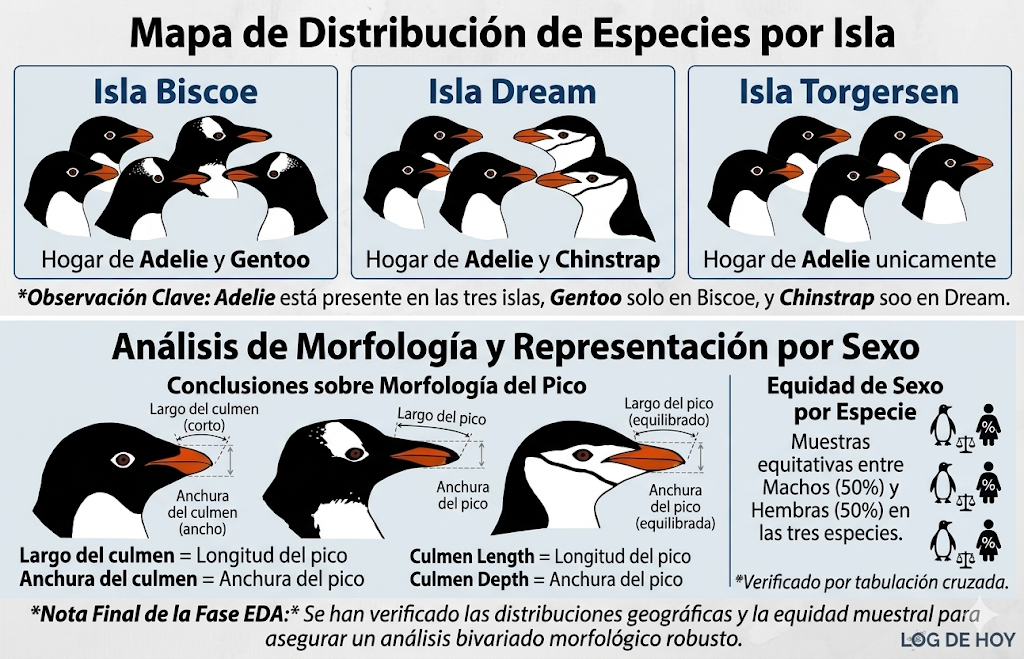

### 6) Limitaciones del análisis

* **Desequilibrios de muestreo**:
```
Existe una ausencia total de datos de la especie Chinstrap en las islas Biscoe y Torgersen, y de Gentoo en Dream y Torgersen. Con los datos actuales, no se puede determinar si es una ausencia real en la naturaleza o un sesgo en la campaña de recogida.
``` 
* **Información faltante**:
```
El dataset no incluye el "Esfuerzo de Muestreo" (cuántas horas o personas buscaron en cada isla). Sin esto, no podemos concluir si la diferencia en la cantidad de observaciones es real o técnica. Podría ser un sesgo de recolección y no una menor densidad real de población. 
```
* **Variables de baja confiabilidad**: 
```
La variable Sex presenta un 3 % de valores faltantes. Aunque la ausencia de valores es una limitación presente en el dataset, el porcentaje es tan pequeño que no debería influir en los resultados del análisis.
```
* **Ausencia de Contexto Temporal/Ambiental**:
```
El análisis se limita a métricas físicas. No podemos concluir si un cambio en una variable morfológica se debe a factores externos (clima, comida), ya que esas variables están fuera del alcance de los datos recolectados.

### 7) Conclusiones y recomendaciones (Hallazgos Accionables)

**Hallazgo 1: Patrón de Distribución por Isla**
```
- Evidencia observada: La especie Adelie aparece en las 3 islas, pero Gentoo y Chinstrap solamente aparecen en una de ellas, Biscoe y Dream, respectivamente.
- Interpretación: Hay un desequilibrio de distribución en los datos recolectados, no podemos determinar si este desequilibrio se debe a la metodología del muestreo o a la distribución real de especies en cada una de las islas.
- Implicación para el cliente: No se pueden realizar comparaciones bivariadas entre especies dentro de la Isla Torgersen (solo hay Adelie).
- Recomendación: En la próxima campaña, documentar cómo se realizó el muestreo, si se realiza de forma aleatoria o si se hace una preselección por especie.
```

**Hallazgo 2: Dimorfismo sexual en la Masa Corporal**
```
- Evidencia observada: En todas las categorías cruzadas, la media de masa de los machos es superior a la de las hembras.
- Interpretación: El sexo es un factor de variabilidad constante en el peso, independientemente de la especie.
- Implicación para el cliente: Un análisis de peso que no segregue por sexo dará una visión distorsionada (bimodal) de la realidad.
- Recomendación: Asegurar la identificación del sexo en el 100% de los individuos capturados para no invalidar las comparaciones de masa.
```

**Hallazgo 3: Patrón de Forma del Pico**
```
- Evidencia observada: Los Adelie tienen picos cortos y anchos, mientras que los Chinstrap tienen picos largos pero también anchos, es decir, más equilibrados, y los Gentoo tienen los picos largos pero más estrechos.
- Interpretación: La relación largo/ancho del pico es el único factor que permite distinguir a los Adelie de los Chinstrap, que por lo demás son muy similares en peso y  tamaño de  las aletas.
- Implicación para el cliente: Para distinguir estas dos especies "pequeñas", se requiere obligatoriamente la medida del culmen.
- Recomendación: En futuras campañas, tratar de reducir el número de datos nulos en la medida de Culmen Depth, ya que es el único diferenciador para el 50% de las especies del dataset.
```

**Hallazgo 4: Distribución de la Especie Adelie**
```
- Evidencia observada: La especie Adelie es la única con registros en las tres islas, representando aproximadamente el 44% del total de observaciones.
- Interpretación: Es la especie con mayor presencia y distribución geográfica en los datos recolectados.
- Implicación para el cliente: Los datos de Adelie son los más robustos para realizar comparaciones transversales entre islas.
- Recomendación: Utilizar a la población de Adelie como grupo de control o referencia para comparar las condiciones de las tres islas, ya que es la única constante en el dataset.
```

**Hallazgo 5: Calidad del Muestreo (Valores Faltantes)**
```
- Evidencia observada: Las variables morfológicas tienen muy pocos nulos (2 casos por cada variable), pero el sexo tiene más (11 casos).
- Interpretación: Las medidas físicas son más fáciles de obtener o registrar que la determinación del sexo.
- Implicación para el cliente: La base de datos es muy confiable para análisis morfológico, pero menos para análisis demográficos por sexo.
- Recomendación: Revisar el protocolo de sexado en campo o incluir pruebas genéticas si los datos de sexo son críticos para el futuro del proyecto.
```

## 8) Checklist de entrega

- [x] Notebook reproducible de inicio a fin
- [x] Diagnostico inicial completo
- [x] Tabla de decisiones de calidad completada
- [x] Analisis univariado y bivariado con foco y justificacion
- [x] Minimo 4 visualizaciones relevantes con interpretacion
- [x] Seccion de limitaciones del analisis
- [x] Minimo 5 conclusiones accionables con estructura completa
- [x] README y trazabilidad de proceso en Git

### 9) Evidencias del equipo

- [Enlace al repositorio del proyecto](https://github.com/Alain-coder1/Proyecto_Curie.git)
- [Sección Wiki roles_y_tareas](https://github.com/Alain-coder1/Proyecto_Curie/wiki/02%E2%80%90Roles_-y_tareas)
- [Evolución del Proyecto](https://github.com/Alain-coder1/Proyecto_Curie/wiki/04%E2%80%90Evoluci%C3%B3n_proyecto)

### Control rapido antes de entregar

| Evidencia | Estado |
|---|---|
| Repositorio compartido actualizado | [x] |
| README con objetivo y equipo | [x] |
| roles_y_tareas.md completo | [x] |
| Historial de commits trazable | [x] |
| Notebook ejecutable de principio a fin | [x] |